**Task 1: MCP Neurons (AND & OR)**

---



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── AND Gate ──────────────────────────────────────────────
def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)
    sums = [x1 + x2 for x1, x2 in zip(X1, X2)]
    state_neuron = [1 if s >= T else 0 for s in sums]
    return state_neuron

X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 2
result = MCP_Neurons_AND(X1, X2, T)
print(f"AND gate output: {result}")
# Expected: [0, 0, 0, 1]

# ── OR Gate ───────────────────────────────────────────────
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)
    sums = [x1 + x2 for x1, x2 in zip(X1, X2)]
    state_neuron = [1 if s >= T else 0 for s in sums]
    return state_neuron

T_or   = 1
result_or = MCP_Neurons_OR(X1, X2, T_or)
print(f"OR  gate output: {result_or}")
# Expected: [0, 1, 1, 1]

AND gate output: [0, 0, 0, 1]
OR  gate output: [0, 1, 1, 1]


Question 1 – Limitations of MCP Neurons

Fixed, hand-crafted threshold — T
must be set manually; there is no learning mechanism to find it automatically.

Binary inputs only — inputs must be 0 or 1; real-valued inputs are not supported.

Equal weights — all inputs contribute equally; the model cannot express that some inputs matter more than others.

No learning algorithm — weights and threshold never update from data.

Cannot solve non-linearly separable problems — XOR, for instance, is impossible with a single MCP neuron.

Inhibitory inputs are all-or-nothing — any inhibitory input forces output to 0, regardless of how strong the excitatory signals are.

Question 2 – Can XOR be solved with a single MCP Neuron?

No. XOR is not linearly separable, so no single threshold rule on the sum x1 + x2 can reproduce it:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 1. Load Data ──────────────────────────────────────────
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI&ML/week3/mnist_0_and_1.csv")
X = df_0_1.drop(columns=["label"]).values   # shape: (n_samples, 784)
y = df_0_1["label"].values                  # shape: (n_samples,)
print("Feature matrix shape:", X.shape)
print("Label vector shape  :", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape  : (12665,)


Q1 – Shape of X:

Rows = number of images (samples); columns = 784 (28×28 pixels per image flattened).

Each column is one pixel feature; each row is one handwritten-digit image.

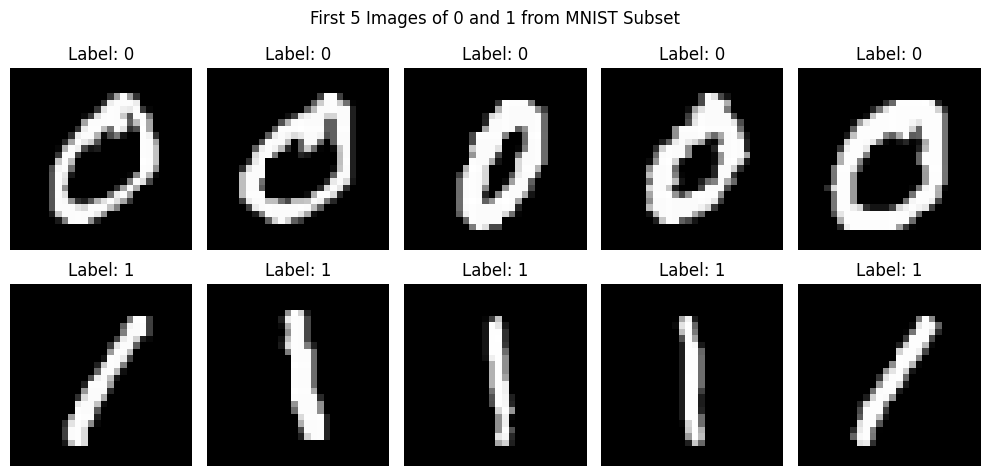

In [ ]:
# ── 2. Visualise ──────────────────────────────────────────
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0"); axes[0, i].axis("off")
    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1"); axes[1, i].axis("off")
plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.tight_layout(); plt.show()

# ── 3. Initialise Weights ─────────────────────────────────
weights       = np.zeros(X.shape[1])   # 784 weights
bias          = 0
learning_rate = 0.1
epochs        = 100

Q3 – What does the weights array represent?

Each element weights[j] is the importance (strength) assigned to pixel j. During training the perceptron learns which pixels are most informative for distinguishing 0 from 1.

Q4 – Why initialise to zero?

Zero is a neutral starting point requiring no prior knowledge. The downside is symmetry: all neurons in a multi-layer network would update identically. For a single perceptron it is acceptable, but random small values are often preferred in deeper networks to break symmetry.

In [ ]:
# ── 4. Decision / Activation Function ────────────────────
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    y_pred_all  = np.where(predictions >= 0, 1, 0)   # step function
    return y_pred_all

# ── 5. Perceptron Learning Algorithm ─────────────────────
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    for epoch in range(epochs):
        convergence_flag = True
        correct = 0

        for i in range(len(X)):
            # Weighted sum
            output = np.dot(X[i], weights) + bias
            # Step activation
            y_hat  = 1 if output >= 0 else 0

            if y_hat != y[i]:                         # mis-classified
                error          = y[i] - y_hat
                weights       += learning_rate * error * X[i]
                bias          += learning_rate * error
                convergence_flag = False
            else:
                correct += 1

        accuracy = correct / len(X)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | Accuracy: {accuracy:.4f}")

        if convergence_flag:
            print(f"Converged at epoch {epoch+1}")
            break

    return weights, bias, accuracy

# ── 6. Train ──────────────────────────────────────────────
weights, bias, accuracy = train_perceptron(X, y, weights, bias,
                                           learning_rate, epochs)
print(f"\nFinal Training Accuracy: {accuracy:.4f}")

Epoch  10 | Accuracy: 0.9992
Converged at epoch 13

Final Training Accuracy: 1.0000


Q5 – Purpose of np.dot(X[i], weights) + bias:

Computes the weighted sum z = Σ wⱼxⱼ + b — the net activation of the perceptron for sample i. It measures how strongly the current weights "vote" for class 1.

Q6 – Weight & bias update when prediction is wrong:

The error (y − ŷ) is ±1. Weights are nudged in the direction of the true class: w ← w + η·error·x. Pixels that contributed to the wrong decision get reduced; pixels aligned with the correct class get amplified. The bias shifts the decision boundary accordingly.

Q7 – Why is final accuracy important?

It tells us whether the perceptron found a separating hyperplane. For 0 vs 1 (very visually distinct digits) we expect ~99–100% accuracy because the classes are nearly linearly separable.

In [ ]:
# ── 7. Visualise Misclassified Images ────────────────────
y_pred            = decision_function(X, weights, bias)
final_accuracy    = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred:{y_pred[idx]} True:{y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images"); plt.tight_layout(); plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Q8 – What does misclassified_idx store?

The array indices of every sample where y_pred[i] ≠ y[i]. It is then used to slice into X and y to display the incorrectly predicted images alongside their true and predicted labels.

Q9 – How to interpret "All images correctly classified"?

The perceptron found a linear decision boundary that perfectly separates all 0s from all 1s in the training set. This is expected here because 0 and 1 are highly dissimilar visually and the data is linearly separable.

Feature matrix shape: (2741, 784)
Label vector shape  : (2741,)


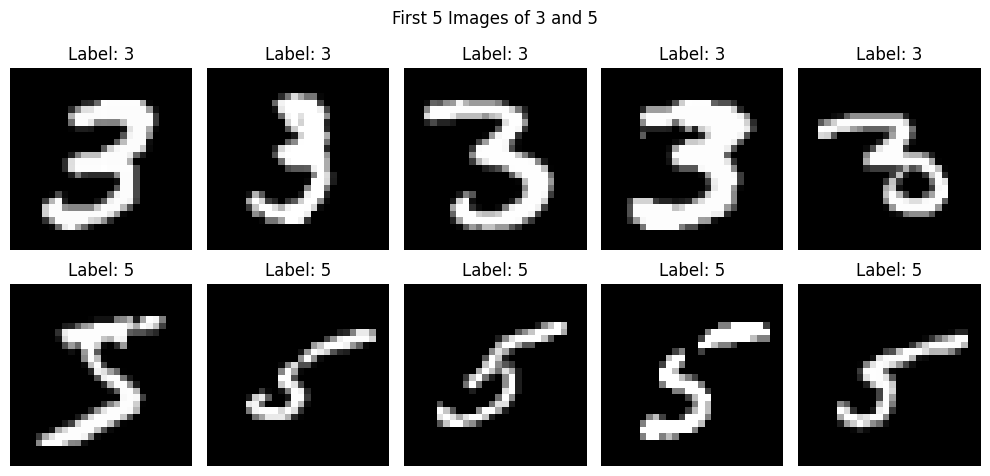

Epoch  10 | Accuracy: 0.9566
Epoch  20 | Accuracy: 0.9661
Epoch  30 | Accuracy: 0.9726
Epoch  40 | Accuracy: 0.9719
Epoch  50 | Accuracy: 0.9788
Epoch  60 | Accuracy: 0.9759
Epoch  70 | Accuracy: 0.9792
Epoch  80 | Accuracy: 0.9792
Epoch  90 | Accuracy: 0.9843
Epoch 100 | Accuracy: 0.9858

Final Training Accuracy (3 vs 5): 0.9858
Final Accuracy: 0.9869


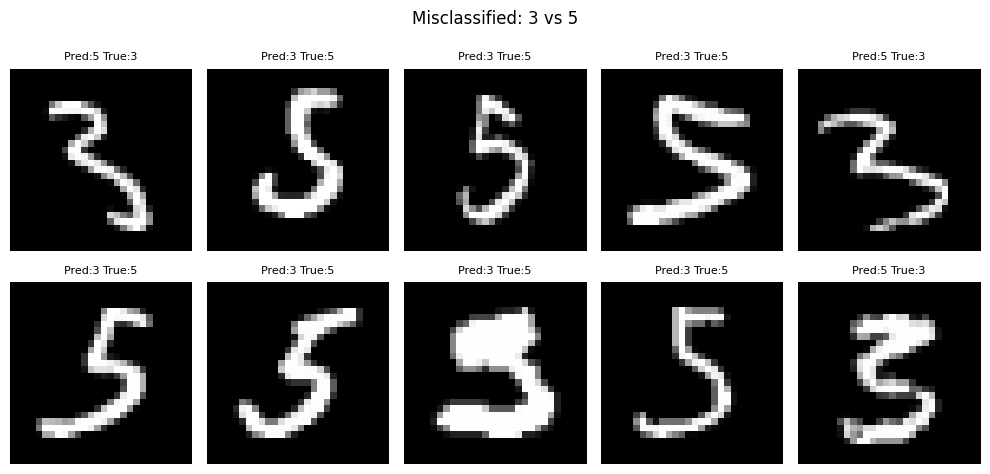

In [ ]:
# ── Load & Prepare ────────────────────────────────────────
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI&ML/week3/mnist_3_and_5.csv")
X35    = df_3_5.drop(columns=["label"]).values
y35    = df_3_5["label"].values

# Map labels to 0/1 for the perceptron (3→0, 5→1)
y35_bin = np.where(y35 == 5, 1, 0)

print("Feature matrix shape:", X35.shape)
print("Label vector shape  :", y35.shape)

# ── Visualise ─────────────────────────────────────────────
images_3 = X35[y35 == 3]
images_5 = X35[y35 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3"); axes[0, i].axis("off")
    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5"); axes[1, i].axis("off")
plt.suptitle("First 5 Images of 3 and 5"); plt.tight_layout(); plt.show()

# ── Train ─────────────────────────────────────────────────
w35   = np.zeros(X35.shape[1])
b35   = 0
w35, b35, acc35 = train_perceptron(X35, y35_bin, w35, b35,
                                    learning_rate=0.1, epochs=100)
print(f"\nFinal Training Accuracy (3 vs 5): {acc35:.4f}")

# ── Evaluate & Visualise Misclassified ───────────────────
y_pred35         = decision_function(X35, w35, b35)
final_acc35      = np.mean(y_pred35 == y35_bin)
print(f"Final Accuracy: {final_acc35:.4f}")

misclassified_35 = np.where(y_pred35 != y35_bin)[0]
if len(misclassified_35) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_35[:10]):
        true_label = 5 if y35_bin[idx] == 1 else 3
        pred_label = 5 if y_pred35[idx] == 1 else 3
        ax.imshow(X35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred:{pred_label} True:{true_label}", fontsize=8)
        ax.axis("off")
    plt.suptitle("Misclassified: 3 vs 5"); plt.tight_layout(); plt.show()
else:
    print("All images were correctly classified!")